# Homework 1: Aircraft inventory analysis

In [209]:
# Load in dataset

import pandas as pd

def load_data():
    # os.system('curl -L -O https://github.com/mosesyhc/de300-2026sp/raw/refs/heads/main/homework/T_F41SCHEDULE_B43_with_missing.zip')
    return pd.read_csv('T_F41SCHEDULE_B43_with_missing.zip')

inventory = load_data()

/tmp/ipykernel_2462/2080711060.py:7: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv('T_F41SCHEDULE_B43_with_missing.zip')


## **Part 1**

In [210]:
# Explore the columns of interest

columns_of_interest = inventory[['CARRIER', 'CARRIER_NAME', 'MANUFACTURE_YEAR',
                             'NUMBER_OF_SEATS', 'CAPACITY_IN_POUNDS', 'AIRLINE_ID']].isnull().sum()
print(columns_of_interest)

CARRIER                  49
CARRIER_NAME            105
MANUFACTURE_YEAR          3
NUMBER_OF_SEATS       13238
CAPACITY_IN_POUNDS    13332
AIRLINE_ID              105
dtype: int64


In [211]:
# Impute missing values in CARRIER, CARRIER_NAME, AIRLINE_ID, MANUFACTURE_YEAR

from sklearn.impute import SimpleImputer

def fix_carrier_columns(df):
  # fix CARIER: replace NaN with "NA"
  df['CARRIER'] = df['CARRIER'].fillna('NA')

  # fix CARRIER_NAME: replace NaN with "North American Airlines"
  df['CARRIER_NAME'] = df['CARRIER_NAME'].fillna('North American Airlines')

  # fix AIRLINE_ID: map existing CARRIER to AIRLINE_ID
  carrier_to_airline_id = (df.dropna(subset=['CARRIER', 'AIRLINE_ID']).drop_duplicates('CARRIER').set_index('CARRIER')['AIRLINE_ID'].to_dict())
  df['AIRLINE_ID'] = df['AIRLINE_ID'].fillna(df['CARRIER'].map(carrier_to_airline_id))

  # fix MANUFACTURE_YEAR: Simple Median Imputation
  median_imputer = SimpleImputer(strategy='median')
  df['MANUFACTURE_YEAR'] = median_imputer.fit_transform(df[['MANUFACTURE_YEAR']])

  return df

inventory = fix_carrier_columns(inventory)

               CAPACITY_MISSING  NUMBER_SEATS_MISSING
AIRCRAFT_TYPE                                        
323                    0.000000                   0.0
351                    0.000000                   0.0
353                    0.000000                   0.0
413                    0.000000                   0.0
673                    1.000000                   0.0
...                         ...                   ...
8381                   0.450593                   0.0
8391                   0.509009                   0.0
8871                   0.344633                   1.0
8881                   0.427051                   0.0
8891                   0.374046                   1.0

[324 rows x 2 columns]


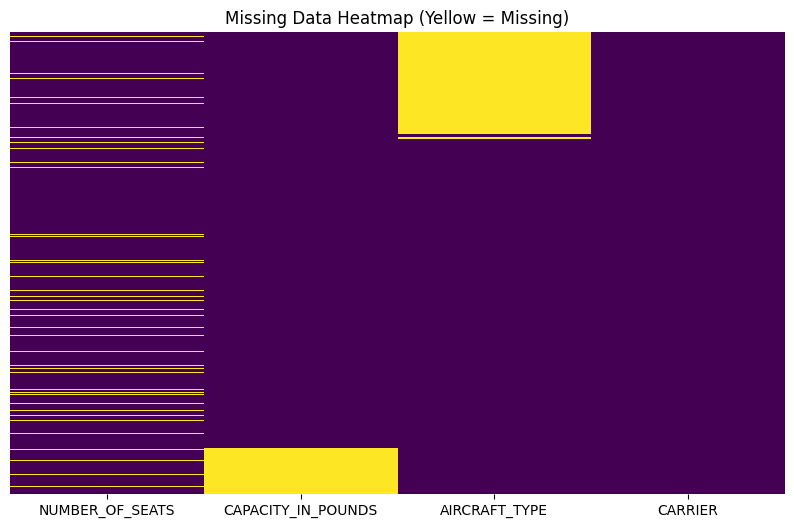

In [212]:
# Explore columns of interest: created boolean column of whether value was missing, and calcualte proportions for each
# Also generated heatmap to analyze where the data was missing

import seaborn as sns
import matplotlib.pyplot as plt

sample_df = inventory[['NUMBER_OF_SEATS', 'CAPACITY_IN_POUNDS', 'AIRCRAFT_TYPE', 'CARRIER']]
inventory['CAPACITY_MISSING'] = inventory['CAPACITY_IN_POUNDS'].isnull().astype(int)
inventory['NUMBER_SEATS_MISSING'] = inventory['NUMBER_OF_SEATS'].isnull().astype(int)

missing_props = inventory.groupby('AIRCRAFT_TYPE')[['CAPACITY_MISSING', 'NUMBER_SEATS_MISSING']].mean()
print(missing_props)

plt.figure(figsize=(10,6))
sns.heatmap(sample_df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Data Heatmap (Yellow = Missing)")
plt.show()

In [213]:
# Impute missing values in NUMBER_OF_SEATS, CAPACITY_IN_POUNDS
from sklearn.impute import KNNImputer

def impute_number_of_seats(df):
  # fix NUMBER_OF_SEATS: Median, grouping by AIRCRAFT_TYPE
  type_median = df.groupby('AIRCRAFT_TYPE')['NUMBER_OF_SEATS'].transform('median')
  df['NUMBER_OF_SEATS'] = df['NUMBER_OF_SEATS'].fillna(type_median)
  return df

def impute_capacity_pounds(df):
  # fix NUMBER_OF_SEATS: Median, grouping by AIRCRAFT_TYPE
  model_median = df.groupby('AIRCRAFT_TYPE')['CAPACITY_IN_POUNDS'].transform('median')
  df['CAPACITY_IN_POUNDS'] = df['CAPACITY_IN_POUNDS'].fillna(model_median)
  return df

inventory = impute_number_of_seats(inventory)
inventory = impute_capacity_pounds(inventory)

## **Part 2**

In [214]:
# Explore the existing, unorganized data for each column of interest

print("MANUFACTURER column before any standardization/transformation")
print(inventory['MANUFACTURER'].value_counts()[inventory['MANUFACTURER'].value_counts() > 50].to_string())

print("\nMODEL column before any tandardization/transformation")
print(inventory['MODEL'].value_counts()[inventory['MODEL'].value_counts() > 100].to_string())

print("\nAIRCRFT_STATUS column before any standardization/transformation")
print(inventory['AIRCRAFT_STATUS'].value_counts(dropna=False))

print("\nOPERATING_STATUS column before any standardization/transformation")
print(inventory['OPERATING_STATUS'].value_counts(dropna=False))

MANUFACTURER column before any standardization/transformation
MANUFACTURER
BOEING                                                                              15922
Embraer                                                                             11508
THEBOEINGCO                                                                          9223
Bombardier                                                                           8871
Boeing                                                                               8392
BoeingCo                                                                             7446
AIRBUS                                                                               7179
AirbusIndustries                                                                     6967
BOEINGCOMPANY                                                                        6767
Airbus                                                                               5289
CESSNA                   

In [215]:
# Standardize/transform AIRCRAFT_STATUS and OPERATING_STATUS

def standardize_columns(df):
  for col in ['AIRCRAFT_STATUS', 'OPERATING_STATUS']:
      df[col] = df[col].str.strip().str.upper()

  df['OPERATING_STATUS'] = df['OPERATING_STATUS'].fillna('None')

  return df


# Standardize/transform MANUFACTURER: clean and combine into groups
def clean_manufacturer(df):
  # Strip whitespace + remove special chars
  df['MANUFACTURER'] = df['MANUFACTURER'].str.strip()
  df['MANUFACTURER'] = df['MANUFACTURER'].str.replace(r'[\s\-\.]', '', regex=True).str.upper()

  # Fix significant names to be more consistent
  manufacturer_map = {
      'THEBOEINGCO': 'BOEING',
      'BOEINGCO': 'BOEING',
      'AIRBUSINDUSTRIES': 'AIRBUS',
      'THEBOEINGCOMPANY': 'BOEING',
      'DOUGLAS': 'MCDONNELL DOUGLAS',
      'MCDONNELDOUGLAS': 'MCDONNELL DOUGLAS',
      'BOMBARDIERAEROSPACE': 'BOMBARDIER',
      'AIRBUSCOMPANY': 'AIRBUS',
      'DOUGLASAIRCRAFT': 'MCDONNELL DOUGLAS',
      'DOUGLAS': 'MCDONNELL DOUGLAS',
      'MCDO': 'MCDONNELL DOUGLAS',
      'AIRBUSINDUSTRIES': 'AIRBUS',
      'AIRBUSCOMPANY': 'AIRBUS',
      'MCDONNELLDOUGLASMD11F': 'MCDONNELL DOUGLAS',
      'MCDONALDDOUGLAS': 'MCDONNELL DOUGLAS',
      'MDDOUGLAS': 'MCDONNELL DOUGLAS',
  }

  df['MANUFACTURER'] = df['MANUFACTURER'].replace(manufacturer_map)
  return df


# Standardize/transform MODEL: clean
def clean_model(df):

  # Make naming conventions more consistent
  df['MODEL'] = (df['MODEL'].str.strip().str.upper().str.replace(r'\s+', ' ', regex=True))
  df['MODEL'] = df['MODEL'].str.replace(r'(PAX|PASSENGER|PASSENGERONLY|PSGR|ALLPAX)$', '', regex=True).str.strip()

  return df

inventory = standardize_columns(inventory)
inventory = clean_manufacturer(inventory)
inventory = clean_model(inventory)

In [216]:
# Explore and verify columns post-imputation

print("\nAIRCRFT_STATUS column after any standardization/transformation")
print(inventory['AIRCRAFT_STATUS'].value_counts(dropna=False))

print("\nOPERATING_STATUS column after any standardization/transformation")
print(inventory['OPERATING_STATUS'].value_counts(dropna=False))


AIRCRFT_STATUS column after any standardization/transformation
AIRCRAFT_STATUS
O    79506
B    43551
A     9134
L      122
Name: count, dtype: int64

OPERATING_STATUS column after any standardization/transformation
OPERATING_STATUS
Y    126648
N      5664
          1
Name: count, dtype: int64


## **Part 3**

In [217]:
# Remove missing data rows and report remaining data

def remove_remaining_missing(df):
    rows_before = len(df)
    df = df.dropna()
    rows_after = len(df)

    print(f"Number of rows removed: {rows_before - rows_after}")
    print(f"Number of data remaining: {rows_after} rows")
    print(f"Proportion of data remaining: {100 * rows_after / rows_before:.1f}%")

    return df

inventory = remove_remaining_missing(inventory)

Number of rows removed: 37172
Number of data remaining: 95141 rows
Proportion of data remaining: 71.9%


## **Part 4**

Skewness of NUMBER_OF_SEATS: -0.3239
Skewness of CAPACITY_IN_POUNDS: 4.0522


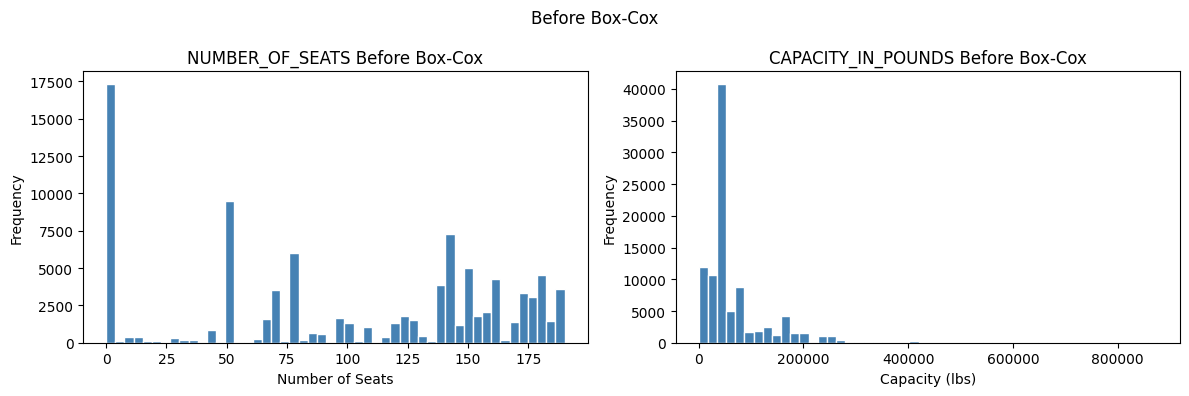

In [218]:
# Check skewness of variables and plot histograms before applying Box-Cox

from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

def plot_before_boxcox(df):
  print(f"Skewness of NUMBER_OF_SEATS: {df['NUMBER_OF_SEATS'].skew():.4f}")
  print(f"Skewness of CAPACITY_IN_POUNDS: {df['CAPACITY_IN_POUNDS'].skew():.4f}")

  # Plots before applying Box-Cox transformation
  fig, axes = plt.subplots(1, 2, figsize=(12, 4))

  axes[0].hist(df['NUMBER_OF_SEATS'], bins=50, color='steelblue', edgecolor='white')
  axes[0].set_title('NUMBER_OF_SEATS Before Box-Cox')
  axes[0].set_xlabel('Number of Seats')
  axes[0].set_ylabel('Frequency')

  axes[1].hist(df['CAPACITY_IN_POUNDS'], bins=50, color='steelblue', edgecolor='white')
  axes[1].set_title('CAPACITY_IN_POUNDS Before Box-Cox')
  axes[1].set_xlabel('Capacity (lbs)')
  axes[1].set_ylabel('Frequency')

  plt.suptitle('Before Box-Cox')
  plt.tight_layout()
  plt.show()

plot_before_boxcox(inventory)


Box-Cox lambda for NUMBER_OF_SEATS: 0.6379
Box-Cox lambda for CAPACITY_IN_POUNDS: 0.3391


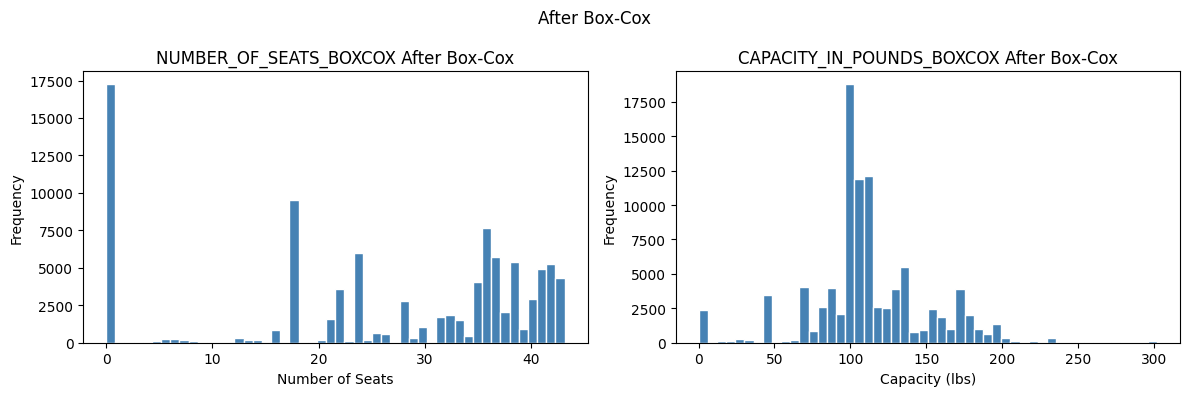

In [219]:
# Apply Box-Cox transformation and plot histograms after

def boxcox(df):
    # Box-Cox requires all values to be positive, so transform any negative values
    number_of_seats = df['NUMBER_OF_SEATS']
    capacity = df['CAPACITY_IN_POUNDS']

    if number_of_seats.min() <= 0:
        number_of_seats = number_of_seats + abs(number_of_seats.min()) + 1
    if capacity.min() <= 0:
        capacity = capacity + abs(capacity.min()) + 1

    df['NUMBER_OF_SEATS_BOXCOX'], lambda_for_seats = stats.boxcox(number_of_seats)
    df['CAPACITY_IN_POUNDS_BOXCOX'], lambda_for_capacity = stats.boxcox(capacity)

    print(f"\nBox-Cox lambda for NUMBER_OF_SEATS: {lambda_for_seats:.4f}")
    print(f"Box-Cox lambda for CAPACITY_IN_POUNDS: {lambda_for_capacity:.4f}")

    return df

def plot_after_boxcox(df):
  fig, axes = plt.subplots(1, 2, figsize=(12, 4))

  axes[0].hist(df['NUMBER_OF_SEATS_BOXCOX'], bins=50, color='steelblue', edgecolor='white')
  axes[0].set_title('NUMBER_OF_SEATS_BOXCOX After Box-Cox')
  axes[0].set_xlabel('Number of Seats')
  axes[0].set_ylabel('Frequency')

  axes[1].hist(df['CAPACITY_IN_POUNDS_BOXCOX'], bins=50, color='steelblue', edgecolor='white')
  axes[1].set_title('CAPACITY_IN_POUNDS_BOXCOX After Box-Cox')
  axes[1].set_xlabel('Capacity (lbs)')
  axes[1].set_ylabel('Frequency')

  plt.suptitle('After Box-Cox')
  plt.tight_layout()
  plt.show()

inventory = boxcox(inventory)
plot_after_boxcox(inventory)

## **Part 5**

In [220]:
# Calculate percentiles and create new SIZE column

def create_column_size(df):
    percentile_25 = df['NUMBER_OF_SEATS'].quantile(0.25)
    percentile_50 = df['NUMBER_OF_SEATS'].quantile(0.50)
    percentile_75 = df['NUMBER_OF_SEATS'].quantile(0.75)

    df['SIZE'] = df['NUMBER_OF_SEATS'].apply(
        lambda seats: 'SMALL' if seats < percentile_25
        else 'MEDIUM' if seats < percentile_50
        else 'LARGE' if seats < percentile_75
        else 'XLARGE'
    )

    return df

inventory = create_column_size(inventory)

Operating Status Proportions for SMALL:
OPERATING_STATUS  STATUS_PROPORTION
               Y           0.952434
               N           0.047532
                           0.000034


/tmp/ipykernel_2462/2852977922.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  status_proportions = (df.groupby('SIZE')['OPERATING_STATUS'].value_counts(normalize=True).rename('STATUS_PROPORTION').reset_index())


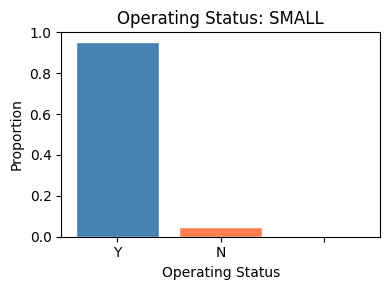

Operating Status Proportions for MEDIUM:
OPERATING_STATUS  STATUS_PROPORTION
               Y           0.956802
               N           0.043198
                           0.000000


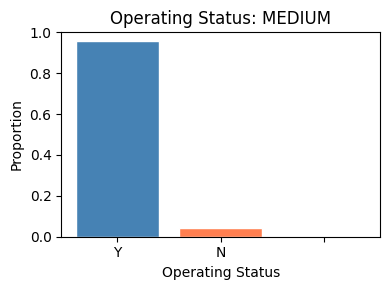

Operating Status Proportions for LARGE:
OPERATING_STATUS  STATUS_PROPORTION
               Y           0.963748
               N           0.036252
                           0.000000


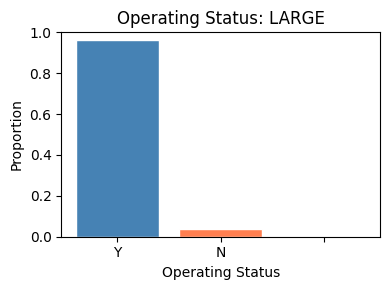

Operating Status Proportions for XLARGE:
OPERATING_STATUS  STATUS_PROPORTION
               Y           0.972907
               N           0.027093
                           0.000000


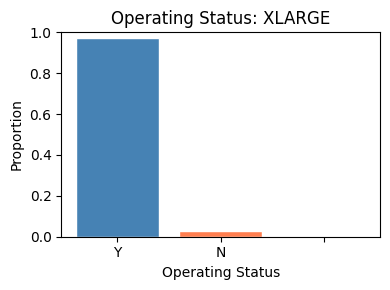

Aircraft Status Proportions for SMALL:
AIRCRAFT_STATUS
O    0.559093
B    0.398461
A    0.042446


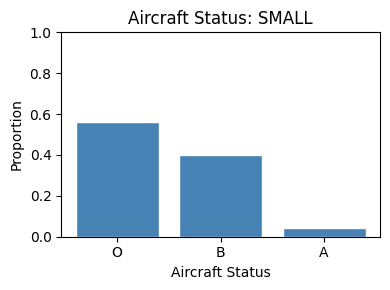

Aircraft Status Proportions for MEDIUM:
AIRCRAFT_STATUS
O    0.529785
B    0.415018
A    0.053650
L    0.001547


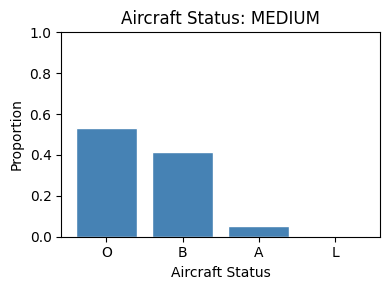

Aircraft Status Proportions for LARGE:
AIRCRAFT_STATUS
O    0.647904
B    0.204556
A    0.145437
L    0.002102


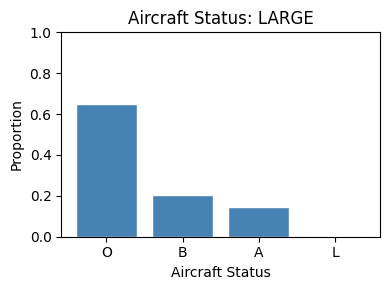

Aircraft Status Proportions for XLARGE:
AIRCRAFT_STATUS
O    0.698198
B    0.231249
A    0.069239
L    0.001314


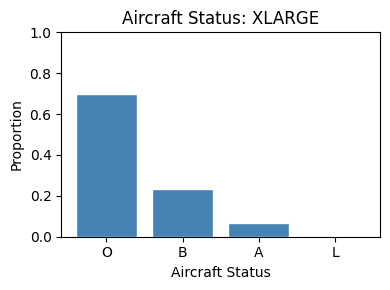

In [221]:
# For each size group, plot proportions of aircrafts that operating versus not

def plot_operating_status_by_size(df):
    status_proportions = (df.groupby('SIZE')['OPERATING_STATUS'].value_counts(normalize=True).rename('STATUS_PROPORTION').reset_index())
    sizes = ['SMALL', 'MEDIUM', 'LARGE', 'XLARGE']

    for i, size in enumerate(sizes):
        subset = status_proportions[status_proportions['SIZE'] == size]
        print(f"Operating Status Proportions for {size}:")
        print(subset[['OPERATING_STATUS', 'STATUS_PROPORTION']].to_string(index=False))

        plt.figure(figsize=(4, 3))
        plt.bar(subset['OPERATING_STATUS'], subset['STATUS_PROPORTION'], color=['steelblue', 'coral'], edgecolor='white')
        plt.title(f'Operating Status: {size}')
        plt.xlabel('Operating Status')
        plt.ylabel('Proportion')
        plt.ylim(0, 1)
        plt.tight_layout()
        plt.show()

    return status_proportions

# For each size group, plot proportions of aircrafts belonging to each aircraft status group
def plot_aircraft_status_by_size(df):
    sizes = ['SMALL', 'MEDIUM', 'LARGE', 'XLARGE']

    for i, size in enumerate(sizes):
        aircraft_subset = df[df['SIZE'] == size]
        aircraft_proportions = aircraft_subset['AIRCRAFT_STATUS'].value_counts(normalize=True)
        print(f"Aircraft Status Proportions for {size}:")
        print(aircraft_proportions.to_string())

        plt.figure(figsize=(4, 3))
        plt.bar(aircraft_proportions.index, aircraft_proportions.values, color='steelblue', edgecolor='white')
        plt.title(f'Aircraft Status: {size}')
        plt.xlabel('Aircraft Status')
        plt.ylabel('Proportion')
        plt.ylim(0, 1)
        plt.tight_layout()
        plt.show()

status_proportions = plot_operating_status_by_size(inventory)
plot_aircraft_status_by_size(inventory)

## **Part 6**

In [222]:
# Prepare the data for models - split into training and test

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

def prepare_data(df, target):
  # Transform categorical columns into numerical values
  features = ['AIRCRAFT_TYPE', 'MANUFACTURER', 'SIZE', 'OPERATING_STATUS', 'AIRCRAFT_STATUS', 'MANUFACTURE_YEAR']
  X = df[features].copy()
  y = df[target]

  for col in ['AIRCRAFT_TYPE', 'MANUFACTURER', 'SIZE', 'OPERATING_STATUS', 'AIRCRAFT_STATUS']:
      X[col] = LabelEncoder().fit_transform(X[col].astype(str))

  return train_test_split(X, y, test_size=0.2, random_state=42)

In [223]:
# Run each model

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

def linear_regression_number_of_seats(df):
    X_train, X_test, y_train, y_test = prepare_data(df, 'NUMBER_OF_SEATS')
    model = LinearRegression()
    model.fit(X_train, y_train)

    train_rmse = np.sqrt(mean_squared_error(y_train, model.predict(X_train)))
    test_rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))

    print(f"Linear Regression for NUMBER_OF_SEATS - Train RMSE: {train_rmse} and Test RMSE: {test_rmse}")
    return model

def random_forest_number_of_seats(df):
    X_train, X_test, y_train, y_test = prepare_data(df, 'NUMBER_OF_SEATS')
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    train_rmse = np.sqrt(mean_squared_error(y_train, model.predict(X_train)))
    test_rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))

    print(f"Random Forest for NUMBER_OF_SEATS - Train RMSE: {train_rmse} and Test RMSE: {test_rmse}")
    return model

def linear_regression_capacity_in_pounds(df):
    X_train, X_test, y_train, y_test = prepare_data(df, 'CAPACITY_IN_POUNDS')
    model = LinearRegression()
    model.fit(X_train, y_train)

    train_rmse = np.sqrt(mean_squared_error(y_train, model.predict(X_train)))
    test_rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))

    print(f"Linear Regression for CAPACITY_IN_POUNDS - Train RMSE: {train_rmse} and Test RMSE: {test_rmse}")
    return model

def random_forest_capacity_in_pounds(df):
    X_train, X_test, y_train, y_test = prepare_data(df, 'CAPACITY_IN_POUNDS')
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    train_rmse = np.sqrt(mean_squared_error(y_train, model.predict(X_train)))
    test_rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))

    print(f"Random Forest for CAPACITY_IN_POUNDS - Train RMSE: {train_rmse} and Test RMSE: {test_rmse}")
    return model

linear_reg_for_seats = linear_regression_number_of_seats(inventory)
random_forest_for_seats = random_forest_number_of_seats(inventory)
linear_reg_forcap = linear_regression_capacity_in_pounds(inventory)
random_forest_for_cap = random_forest_capacity_in_pounds(inventory)

Linear Regression for NUMBER_OF_SEATS - Train RMSE: 60.752630735387505 and Test RMSE: 61.39327048005522
Random Forest for NUMBER_OF_SEATS - Train RMSE: 3.1191047330849315 and Test RMSE: 3.3498282984782684
Linear Regression for CAPACITY_IN_POUNDS - Train RMSE: 68058.30652780875 and Test RMSE: 69150.91750457529
Random Forest for CAPACITY_IN_POUNDS - Train RMSE: 35304.41113309873 and Test RMSE: 39378.74797209004
